### ***Pytorch Fundamentals***

In [1]:
import torch 
import torch.nn as nn 

# Input 
torch.manual_seed(42)
inputs = torch.tensor([1.0, 2.0, 3.0])

# Implment Perceptron 
neuron = nn.Linear(in_features=3, out_features=1)
outputs = neuron(inputs)
outputs

tensor([1.5244], grad_fn=<ViewBackward0>)

In [2]:
# verify ... formula
neuron.weight @ inputs + neuron.bias
neuron.bias

Parameter containing:
tensor([0.5304], requires_grad=True)

***
### ***ANN For Regression***

In [3]:
import pandas as pd 
import numpy as np 

# Load Dataset 
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.shape

(9568, 5)

In [5]:
## Inputs
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

## Output 
# PE => produced energy

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop('PE',axis=1)
y = df['PE']

# Train Test Split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [8]:
X.shape

(9568, 4)

In [9]:
# Standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_Train_Scale  = scaler.fit_transform(X_train)
X_Test_Scale = scaler.transform(X_test)

In [10]:
X_Test_Scale

array([[ 1.35027377,  0.23835089, -1.2868797 , -1.1152662 ],
       [ 0.81612819,  1.36219539, -0.74354734,  0.25518223],
       [-0.23877586, -0.73921294,  1.9883008 , -0.20689783],
       ...,
       [ 0.23512774,  0.27059555,  0.93538342, -0.23848131],
       [-1.79971257, -1.42106962,  2.6025026 ,  1.16698358],
       [ 1.16285427,  0.78729663, -0.34195385, -0.32361939]])

In [11]:
X_Test_Scale

array([[ 1.35027377,  0.23835089, -1.2868797 , -1.1152662 ],
       [ 0.81612819,  1.36219539, -0.74354734,  0.25518223],
       [-0.23877586, -0.73921294,  1.9883008 , -0.20689783],
       ...,
       [ 0.23512774,  0.27059555,  0.93538342, -0.23848131],
       [-1.79971257, -1.42106962,  2.6025026 ,  1.16698358],
       [ 1.16285427,  0.78729663, -0.34195385, -0.32361939]])

In [12]:
# Now Make Tensors 
import torch 
import torch.nn as nn 

# Training
X_train_tensor = torch.tensor(X_Train_Scale,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

# Testing 
X_test_tensor = torch.tensor(X_Test_Scale,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [13]:
type(X_Test_Scale)

numpy.ndarray

In [14]:
type(y_train)
y_train.shape

(6697,)

In [15]:
from torch.utils.data import TensorDataset,DataLoader

train_data = TensorDataset(X_train_tensor,y_train_tensor)
test_data = TensorDataset(X_test_tensor,y_test_tensor)

train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
test_loader = DataLoader(test_data,batch_size=32)

In [16]:
# Let's Build Our Model 
class ANN(nn.Module): 
    def __init__(self): 
        super(ANN,self).__init__()
        self.model = nn.Sequential(
            
            # 1st hidden layer  
            nn.Linear(X_train.shape[1],6), 
            nn.ReLU(), 
            
            # 2nd Hidden Layer 
            nn.Linear(6,6),
            nn.ReLU(), 
            
            #Output Layer 
            nn.Linear(6,1)
        )
        # Forward Propagation 
    def forward(self,x): 
            return self.model(x)

In [17]:
import torch.optim as optim 
model = ANN()

# loss & optimizer  
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [18]:
train_losses = []
val_losses = []
best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):

    # 🔹 Training
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb # compute loss

        loss.backward()
        optimizer.step() # params update

        running_loss += loss.item()

    # ✅ AFTER loop
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # 🔹 Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # 🔹 Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "Model.pt")

Epoch 1/100 | Train Loss: 206116.7225 | Val Loss: 205160.6627
Epoch 2/100 | Train Loss: 200978.7836 | Val Loss: 193625.0333
Epoch 3/100 | Train Loss: 179529.5528 | Val Loss: 161623.5443
Epoch 4/100 | Train Loss: 138029.3653 | Val Loss: 112884.5096
Epoch 5/100 | Train Loss: 87598.3766 | Val Loss: 64656.2208
Epoch 6/100 | Train Loss: 47314.6643 | Val Loss: 34268.8300
Epoch 7/100 | Train Loss: 27048.3510 | Val Loss: 22352.0459
Epoch 8/100 | Train Loss: 19845.0566 | Val Loss: 18040.8595
Epoch 9/100 | Train Loss: 16615.7106 | Val Loss: 15210.5362
Epoch 10/100 | Train Loss: 13894.6489 | Val Loss: 12571.6163
Epoch 11/100 | Train Loss: 11320.0607 | Val Loss: 10017.1829
Epoch 12/100 | Train Loss: 8865.2535 | Val Loss: 7628.5576
Epoch 13/100 | Train Loss: 6589.3144 | Val Loss: 5532.0278
Epoch 14/100 | Train Loss: 4692.8777 | Val Loss: 3858.1845
Epoch 15/100 | Train Loss: 3243.3247 | Val Loss: 2656.5728
Epoch 16/100 | Train Loss: 2247.3296 | Val Loss: 1850.3210
Epoch 17/100 | Train Loss: 1554.387

In [19]:
print(len(train_losses))
print(len(val_losses))

100
100


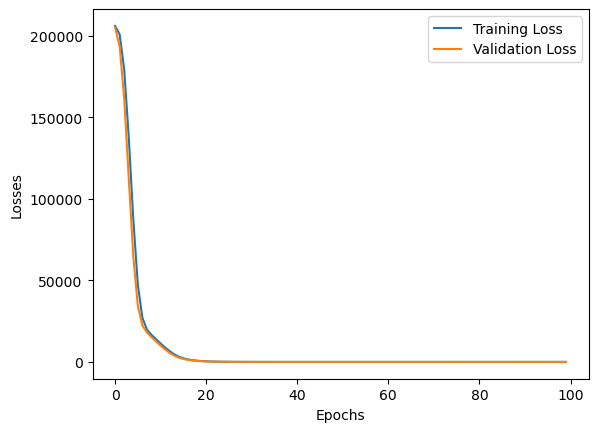

In [20]:
# Visualize Our Model 
import matplotlib.pyplot as plt  

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [21]:
## Loading Model 
model.load_state_dict(torch.load("Model.pt"))

<All keys matched successfully>

In [22]:
# Evaluation 
model.eval()
with torch.no_grad(): 
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    train_mse_loss = criterion(train_pred,y_train_tensor)
    test_mse_loss = criterion(test_pred,y_test_tensor)

print(f"Training MSE:{train_mse_loss.item()}")
print(f"Testing MSE:{test_mse_loss.item()}")

Training MSE:20.581302642822266
Testing MSE:19.307300567626953


In [25]:
from sklearn.metrics import r2_score
print(f"R2 Score:{r2_score(y_test,test_pred)*100}%")

R2 Score:93.295309320067%


In [26]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.705750,433.27
1,436.860565,438.16
2,461.563354,458.42
3,476.486084,480.82
4,435.428345,441.41
...,...,...
2866,480.597717,480.31
2867,453.277100,446.77
2868,450.849182,454.66
2869,484.000763,483.77
